## Dataset Visualization

### Reading Data

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../data/processed/feature_engineered.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

customer_metrics = pd.read_csv('../data/processed/customer_metrics.csv')

In [35]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,Year,Month,DayOfWeek,HourOfDay,TimeOfDay
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,2,8,Morning
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,2,8,Morning
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,2,8,Morning
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,2,8,Morning
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,2,8,Morning


### 1.Customer Purchase Patterns Over Time

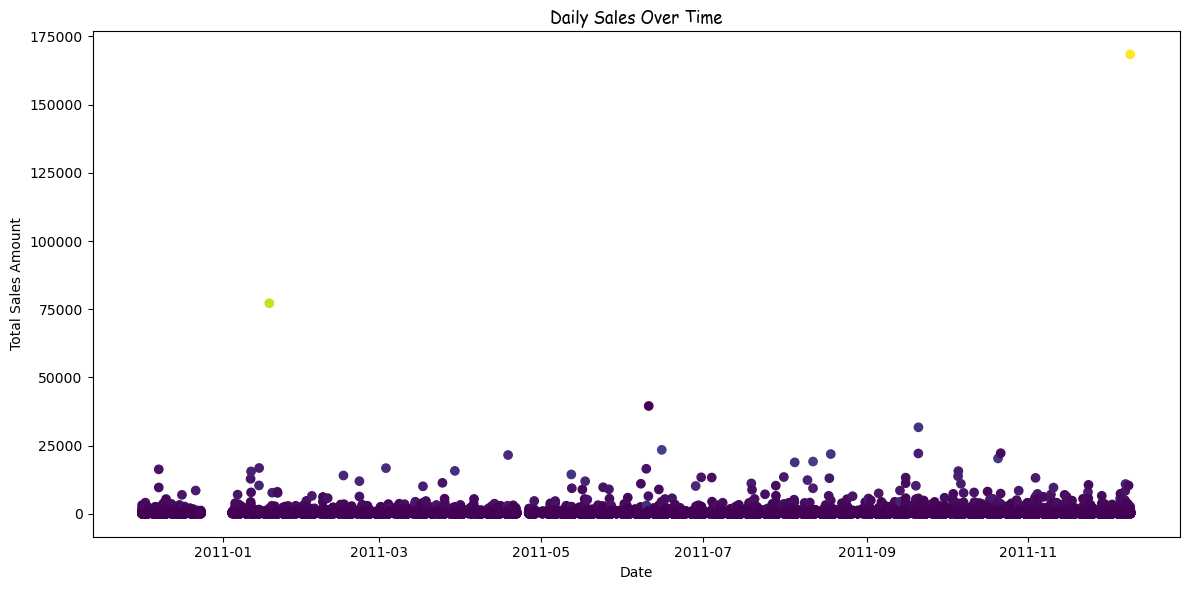

In [36]:
plt.figure(figsize=(12, 6))
daily_sales = df.groupby('InvoiceDate')[['TotalAmount', 'Quantity']].sum().reset_index()
plt.scatter(daily_sales['InvoiceDate'], daily_sales['TotalAmount'],c=daily_sales['Quantity'])
plt.title('Daily Sales Over Time', fontdict={'fontname':'Comic Sans MS'})
plt.xlabel('Date')
plt.ylabel('Total Sales Amount')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 2.Sales By Time Of Day

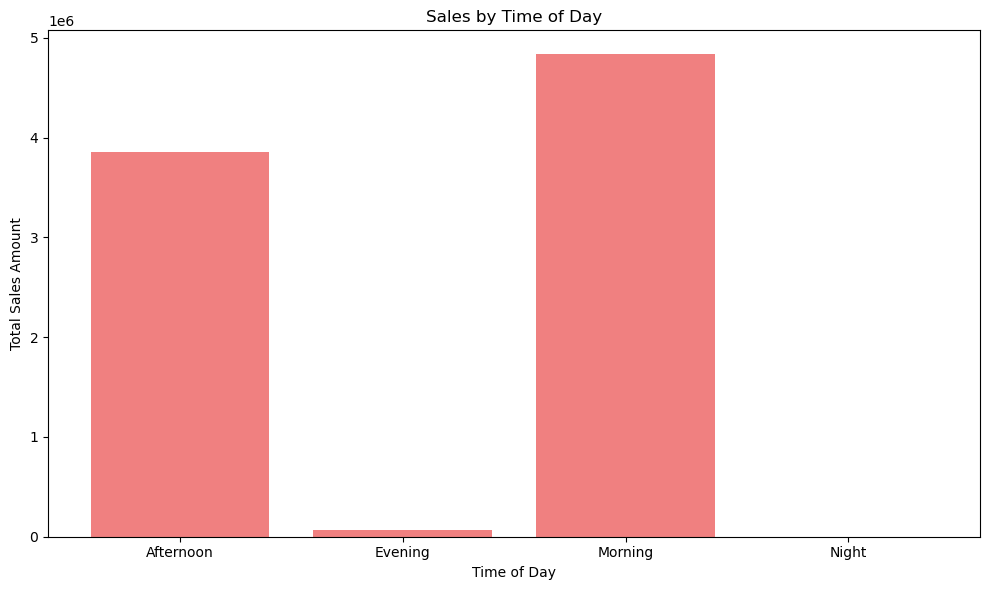

In [37]:
plt.figure(figsize=(10, 6))
time_of_day_sales = df.groupby('TimeOfDay')['TotalAmount'].sum().reset_index()
plt.bar(time_of_day_sales['TimeOfDay'], time_of_day_sales['TotalAmount'], color='lightcoral')
plt.title('Sales by Time of Day')
plt.xlabel('Time of Day')
plt.ylabel('Total Sales Amount')
plt.tight_layout()
plt.show()

### 3.Customer Segmentation By Purchase Frequency & Value

In [38]:
max_frequency = customer_metrics['PurchaseFrequency'].max()
customer_metrics_filtered_freq_outlier = customer_metrics[customer_metrics['PurchaseFrequency'] < max_frequency]

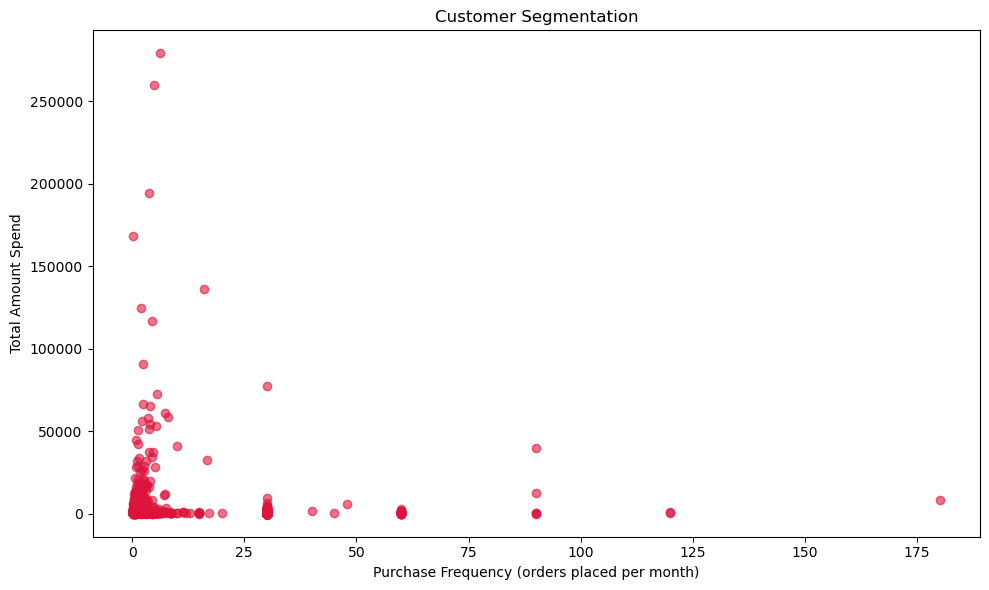

In [39]:
plt.figure(figsize=(10, 6))
plt.scatter(customer_metrics_filtered_freq_outlier['PurchaseFrequency'],
            customer_metrics_filtered_freq_outlier['TotalSpent'],
            alpha=0.6,
            color='crimson')
plt.title('Customer Segmentation')
plt.xlabel('Purchase Frequency (orders placed per month)')
plt.ylabel('Total Amount Spend')
plt.tight_layout()
plt.show()

### 4.Product Analysis

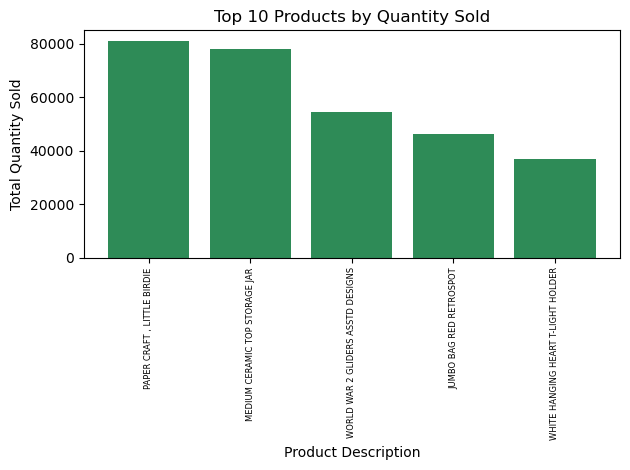

In [40]:
top_5_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(5)

plt.Figure(figsize=(12, 6))
plt.bar(top_5_products.index, top_5_products.values, color='seagreen')
plt.title('Top 10 Products by Quantity Sold')
plt.xlabel('Product Description')
plt.ylabel('Total Quantity Sold')
plt.xticks(fontsize=6, rotation=90)
plt.tight_layout()
plt.show()